In [1]:
from pathlib import Path
import re
import pandas as pd

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_IMAGES_DIR = PROJECT_ROOT / "data" / "raw" / "images"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

image_files = list(RAW_IMAGES_DIR.glob("*.jpg"))

def extract_case_id(image_path):
    """
    Extract case/page number from names like:
    ١_page-0001.jpg
    ٢_page-00025.jpg
    ٤_page-00089.jpg
    """
    name = image_path.name
    
    match = re.search(r"page-(\d+)", name)
    
    if match:
        return int(match.group(1))
    
    return None

image_mapping = pd.DataFrame({
    "image_name": [img.name for img in image_files],
    "image_path": [str(img) for img in image_files],
    "case_id": [extract_case_id(img) for img in image_files]
})

image_mapping = image_mapping.sort_values("case_id").reset_index(drop=True)

print("Number of images:", len(image_mapping))
image_mapping.head()

Number of images: 89


,image_name,image_path,case_id
0,١_page-0001.jpg,d:\FCAI\Year 3\2nd semster\Cognitive\bender-ge...,1
1,١_page-0002.jpg,d:\FCAI\Year 3\2nd semster\Cognitive\bender-ge...,2
2,١_page-0003.jpg,d:\FCAI\Year 3\2nd semster\Cognitive\bender-ge...,3
3,١_page-0004.jpg,d:\FCAI\Year 3\2nd semster\Cognitive\bender-ge...,4
4,١_page-0005.jpg,d:\FCAI\Year 3\2nd semster\Cognitive\bender-ge...,5


In [2]:
print("Min case_id:", image_mapping["case_id"].min())
print("Max case_id:", image_mapping["case_id"].max())

missing_cases = set(range(1, 90)) - set(image_mapping["case_id"])

print("Missing cases:", missing_cases)

Min case_id: 1
Max case_id: 89
Missing cases: set()


In [3]:
mapping_path = PROCESSED_DIR / "image_mapping.csv"

image_mapping.to_csv(mapping_path, index=False, encoding="utf-8-sig")

print("Saved:", mapping_path)

Saved: d:\FCAI\Year 3\2nd semster\Cognitive\bender-gestalt-project\data\processed\image_mapping.csv


### start preprocessing

In [4]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_IMAGES_DIR = PROCESSED_DIR / "processed_images"

GRAY_DIR = PROCESSED_IMAGES_DIR / "gray"
BINARY_DIR = PROCESSED_IMAGES_DIR / "binary"
SKELETON_DIR = PROCESSED_IMAGES_DIR / "skeleton"

for folder in [GRAY_DIR, BINARY_DIR, SKELETON_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

mapping_path = PROCESSED_DIR / "image_mapping.csv"
image_mapping = pd.read_csv(mapping_path)

image_mapping.head()

,image_name,image_path,case_id
0,١_page-0001.jpg,d:\FCAI\Year 3\2nd semster\Cognitive\bender-ge...,1
1,١_page-0002.jpg,d:\FCAI\Year 3\2nd semster\Cognitive\bender-ge...,2
2,١_page-0003.jpg,d:\FCAI\Year 3\2nd semster\Cognitive\bender-ge...,3
3,١_page-0004.jpg,d:\FCAI\Year 3\2nd semster\Cognitive\bender-ge...,4
4,١_page-0005.jpg,d:\FCAI\Year 3\2nd semster\Cognitive\bender-ge...,5


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

In [6]:
## this function made to handle the arabic char in image file names, bc CV2 does not support arabic char in file names

def read_image_unicode(image_path):
    image_path = str(image_path)
    
    image_array = np.fromfile(image_path, dtype=np.uint8)
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    
    return image

In [7]:
def preprocess_image(image_path):
    # Read image
    image = read_image_unicode(image_path)
    
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    # 1. Grayscale: keeps pencil pressure information
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # 2. Mild denoising: reduce paper grain without killing faint strokes
    denoised = cv2.medianBlur(gray, 3)
    
    # 3. Contrast enhancement: helps faint pencil strokes appear
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    enhanced = clahe.apply(denoised)
    
    # 4. Adaptive thresholding: separates drawing strokes from paper background
    binary = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        35,
        10
    )
    
    # 5. Skeletonization: preserves Gestalt while simplifying strokes
    skeleton = skeletonize(binary > 0)
    skeleton_uint8 = (skeleton.astype(np.uint8)) * 255
    
    return {
        "gray": gray,
        "enhanced": enhanced,
        "binary": binary,
        "skeleton": skeleton_uint8
    }

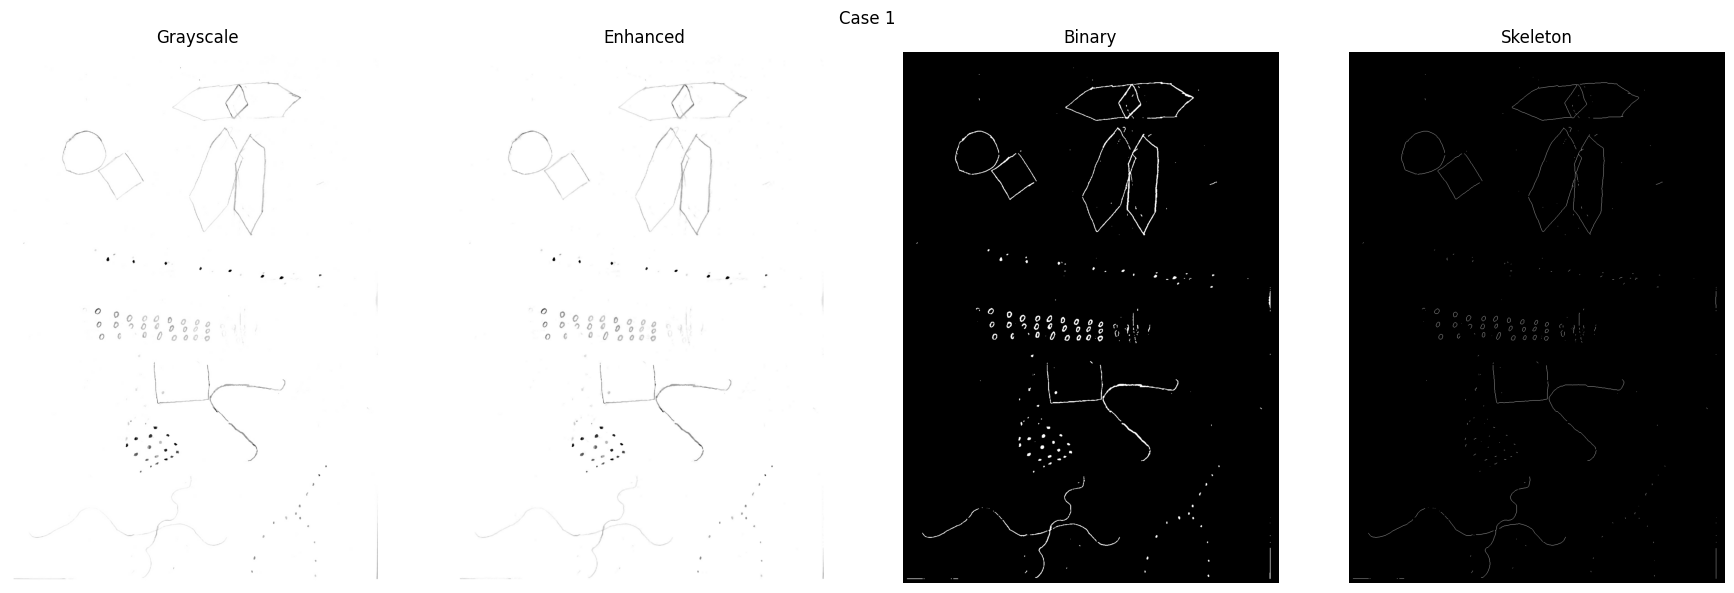

In [8]:
## test for one image to see the results of the preprocessing steps

first_row = image_mapping.iloc[0]

image_path = Path(first_row["image_path"])
case_id = int(first_row["case_id"])

result = preprocess_image(image_path)

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

axes[0].imshow(result["gray"], cmap="gray")
axes[0].set_title("Grayscale")

axes[1].imshow(result["enhanced"], cmap="gray")
axes[1].set_title("Enhanced")

axes[2].imshow(result["binary"], cmap="gray")
axes[2].set_title("Binary")

axes[3].imshow(result["skeleton"], cmap="gray")
axes[3].set_title("Skeleton")

for ax in axes:
    ax.axis("off")

plt.suptitle(f"Case {case_id}")
plt.tight_layout()
plt.show()

In [9]:
for _, row in image_mapping.iterrows():
    image_path = Path(row["image_path"])
    case_id = int(row["case_id"])
    
    result = preprocess_image(image_path)
    
    cv2.imwrite(str(GRAY_DIR / f"case_{case_id:03d}_gray.png"), result["gray"])
    cv2.imwrite(str(BINARY_DIR / f"case_{case_id:03d}_binary.png"), result["binary"])
    cv2.imwrite(str(SKELETON_DIR / f"case_{case_id:03d}_skeleton.png"), result["skeleton"])

print("Done saving preprocessed images.")

Done saving preprocessed images.


In [10]:
print("Gray images:", len(list(GRAY_DIR.glob("*.png"))))
print("Binary images:", len(list(BINARY_DIR.glob("*.png"))))
print("Skeleton images:", len(list(SKELETON_DIR.glob("*.png"))))

Gray images: 89
Binary images: 89
Skeleton images: 89


## make the same in template featuers

In [11]:




TEMPLATE_RAW_DIR = PROJECT_ROOT / "data" / "raw" / "templates"

TEMPLATE_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "template_images"
TEMPLATE_GRAY_DIR = TEMPLATE_PROCESSED_DIR / "gray"
TEMPLATE_BINARY_DIR = TEMPLATE_PROCESSED_DIR / "binary"
TEMPLATE_SKELETON_DIR = TEMPLATE_PROCESSED_DIR / "skeleton"


template_files = sorted(list(TEMPLATE_RAW_DIR.glob("*.jpg")))

print("Number of templates:", len(template_files))
template_files

Number of templates: 9


[WindowsPath('d:/FCAI/Year 3/2nd semster/Cognitive/bender-gestalt-project/data/raw/templates/template_01.jpg'),
 WindowsPath('d:/FCAI/Year 3/2nd semster/Cognitive/bender-gestalt-project/data/raw/templates/template_02.jpg'),
 WindowsPath('d:/FCAI/Year 3/2nd semster/Cognitive/bender-gestalt-project/data/raw/templates/template_03.jpg'),
 WindowsPath('d:/FCAI/Year 3/2nd semster/Cognitive/bender-gestalt-project/data/raw/templates/template_04.jpg'),
 WindowsPath('d:/FCAI/Year 3/2nd semster/Cognitive/bender-gestalt-project/data/raw/templates/template_05.jpg'),
 WindowsPath('d:/FCAI/Year 3/2nd semster/Cognitive/bender-gestalt-project/data/raw/templates/template_06.jpg'),
 WindowsPath('d:/FCAI/Year 3/2nd semster/Cognitive/bender-gestalt-project/data/raw/templates/template_07.jpg'),
 WindowsPath('d:/FCAI/Year 3/2nd semster/Cognitive/bender-gestalt-project/data/raw/templates/template_08.jpg'),
 WindowsPath('d:/FCAI/Year 3/2nd semster/Cognitive/bender-gestalt-project/data/raw/templates/template_09

In [12]:
for i, template_path in enumerate(template_files, start=1):
    result = preprocess_image(template_path)
    
    cv2.imwrite(str(TEMPLATE_GRAY_DIR / f"template_{i:02d}_gray.png"), result["gray"])
    cv2.imwrite(str(TEMPLATE_BINARY_DIR / f"template_{i:02d}_binary.png"), result["binary"])
    cv2.imwrite(str(TEMPLATE_SKELETON_DIR / f"template_{i:02d}_skeleton.png"), result["skeleton"])

print("Done preprocessing templates.")

Done preprocessing templates.
